# Simple thresholding

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('image.png')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [2]:
def show_image(img, title):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

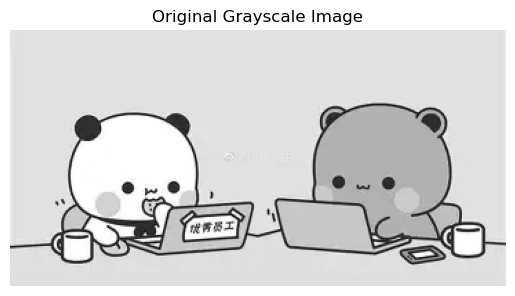

In [3]:
show_image(gray_image, 'Original Grayscale Image')

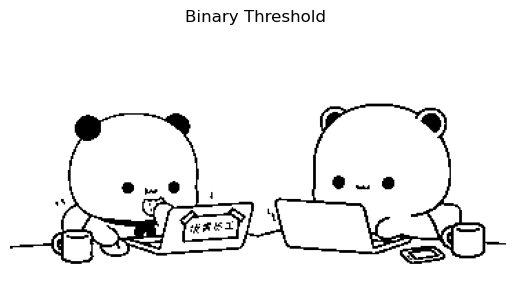

In [4]:
_, thresh_binary = cv2.threshold(gray_image, 120, 255, cv2.THRESH_BINARY)
show_image(thresh_binary, 'Binary Threshold ')

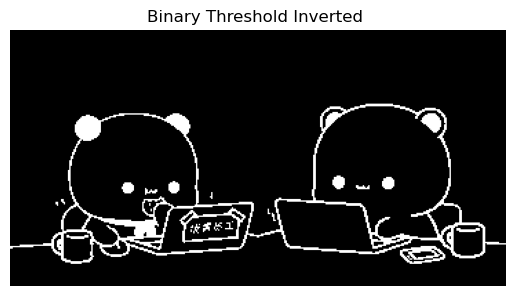

In [5]:
_, thresh_binary_inv = cv2.threshold(
    gray_image, 120, 255, cv2.THRESH_BINARY_INV)
show_image(thresh_binary_inv, 'Binary Threshold Inverted ')

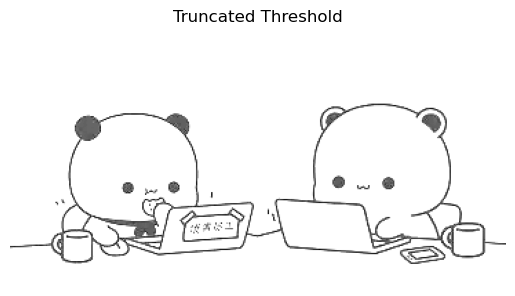

In [6]:
_, thresh_trunc = cv2.threshold(gray_image, 120, 255, cv2.THRESH_TRUNC)
show_image(thresh_trunc, 'Truncated Threshold')

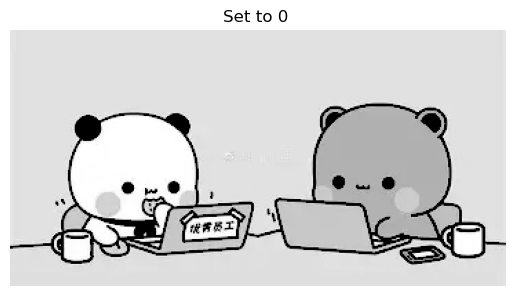

In [7]:
_, thresh_tozero = cv2.threshold(gray_image, 120, 255, cv2.THRESH_TOZERO)
show_image(thresh_tozero, 'Set to 0 ')

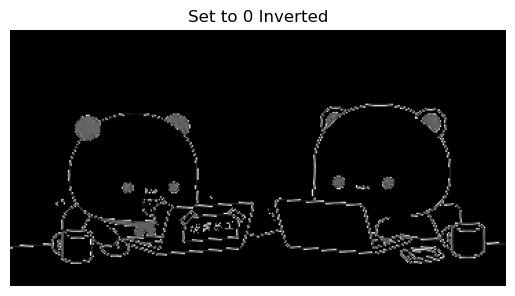

In [8]:
_, thresh_tozero_inv = cv2.threshold(
    gray_image, 120, 255, cv2.THRESH_TOZERO_INV)
show_image(thresh_tozero_inv, 'Set to 0 Inverted')

# Adaptive thresholding

In [9]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('image.png')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [10]:
def show_image(img, title):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

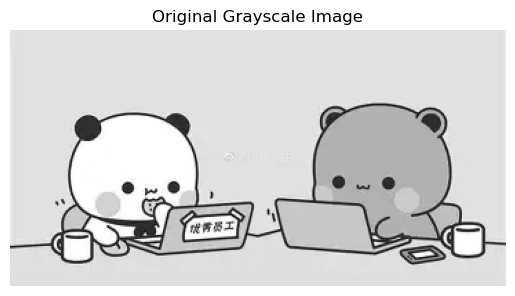

In [11]:
show_image(gray_image, "Original Grayscale Image")

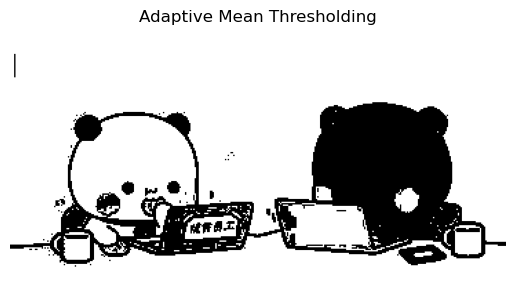

In [12]:
thresh_mean = cv2.adaptiveThreshold(
    gray_image, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    199, 5
)
show_image(thresh_mean, "Adaptive Mean Thresholding")

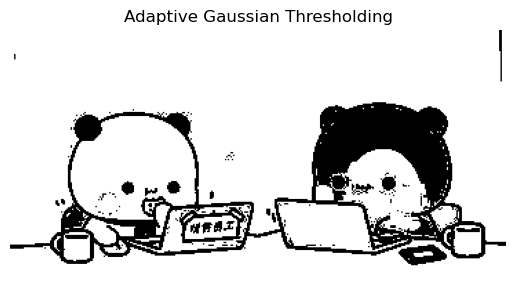

In [13]:
thresh_gauss = cv2.adaptiveThreshold(
    gray_image, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    199, 5
)
show_image(thresh_gauss, "Adaptive Gaussian Thresholding")

# Otsu thresholding

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('image.png')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [17]:
def show_image(img, title):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

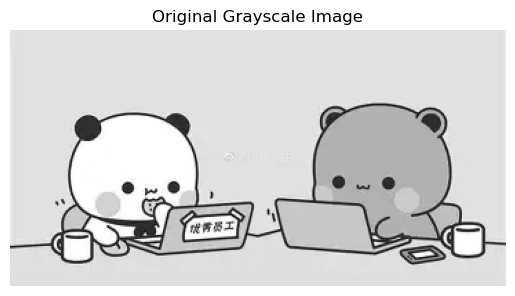

In [18]:
show_image(gray_image, "Original Grayscale Image")

Calculated Otsu threshold value: 138.0


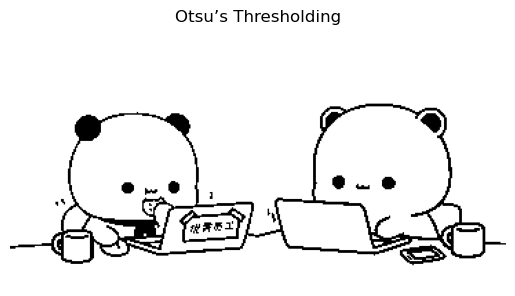

In [19]:
ret, otsu_thresh = cv2.threshold(
    gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Calculated Otsu threshold value:", ret)
show_image(otsu_thresh, "Otsu’s Thresholding")

# Image segmentation using morphological operations

In [21]:
import numpy as np
import cv2
from matplotlib import pyplot as plt


In [33]:
import cv2
import numpy as np

# Provide the full path of the image on your PC
import os
file_path = r"C:\FOURTH SEMESTER\Programming for AI(lab)\Task # 5\image.png"
print(os.path.exists(file_path))  # Should print True
# Read the image in color
img = cv2.imread(file_path, cv2.IMREAD_COLOR)  # Correct flag

# Check if image loaded successfully
if img is None:
    print("Error: Image not found! Check the file path.")
else:
    cv2.imshow("Image", img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

True


In [34]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

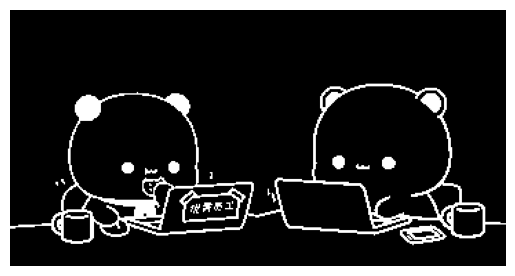

In [35]:
ret, thresh = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.show()

In [36]:
kernel = np.ones((9, 9), np.uint8)
closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)

bg = cv2.dilate(closing, kernel, iterations=2)

In [37]:
contours, _ = cv2.findContours(
    closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
result = np.zeros(gray.shape, dtype=np.uint8)
for contour in contours:
    if cv2.contourArea(contour) > 1000:
        cv2.fillPoly(result, [contour], 255)

In [38]:
kernel_open = np.ones((6, 6), np.uint8)
opened_result = cv2.morphologyEx(
    result, cv2.MORPH_OPEN, kernel_open, iterations=2)

kernel_erode = np.ones((9, 9), np.uint8)
final_result = cv2.erode(opened_result, kernel_erode, iterations=2)

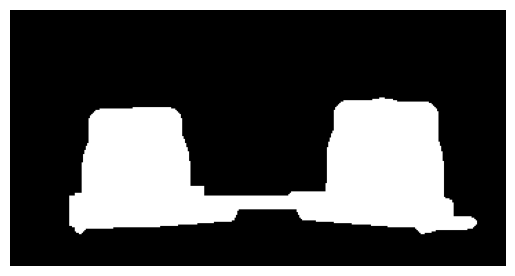

In [39]:
final_result = cv2.erode(opened_result, kernel_erode, iterations=2)
plt.imshow(final_result, cmap='gray')
plt.axis('off')
plt.show()